In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from dating_market import DatingMarket
import statsmodels.formula.api as smf, statsmodels.api as sm

In [ ]:
def couples_quality(market):
    vals = [market.compatibility(a.id, a.partner)
            for a in market.subjects if not a.is_single]
    return float(np.mean(vals)) if vals else np.nan

def matched_fraction(market):
    return float(np.mean([not a.is_single for a in market.subjects]))

def run_once(rejection_cost, rationality, gender_balance, seed,
             n=240, n_grid=50, n_steps=200, burn_in=80,
             memory_depth=8, relation_threshold=0.6):
    m = DatingMarket(n_grid=n_grid, interaction_std=0.5, interaction_radius=5,
                     relationship_length=10, seed=seed)
    m.add_agents(n, gender_balance=gender_balance, rejection_cost=rejection_cost,
                 rationality=rationality, relation_threshold=relation_threshold,
                 memory_depth=memory_depth, move_prob=0.5)
    q, mf = [], []
    for t in range(n_steps):
        m.step()
        if t >= burn_in:
            q.append(couples_quality(m))
            mf.append(matched_fraction(m))
    return np.nanmean(q), np.nanmean(mf)

def replicate(seeds=range(10), **kw):
    res = np.array([run_once(seed=s, **kw) for s in seeds])
    q, mf = res[:, 0], res[:, 1]
    return q.mean(), q.std(), mf.mean(), mf.std()


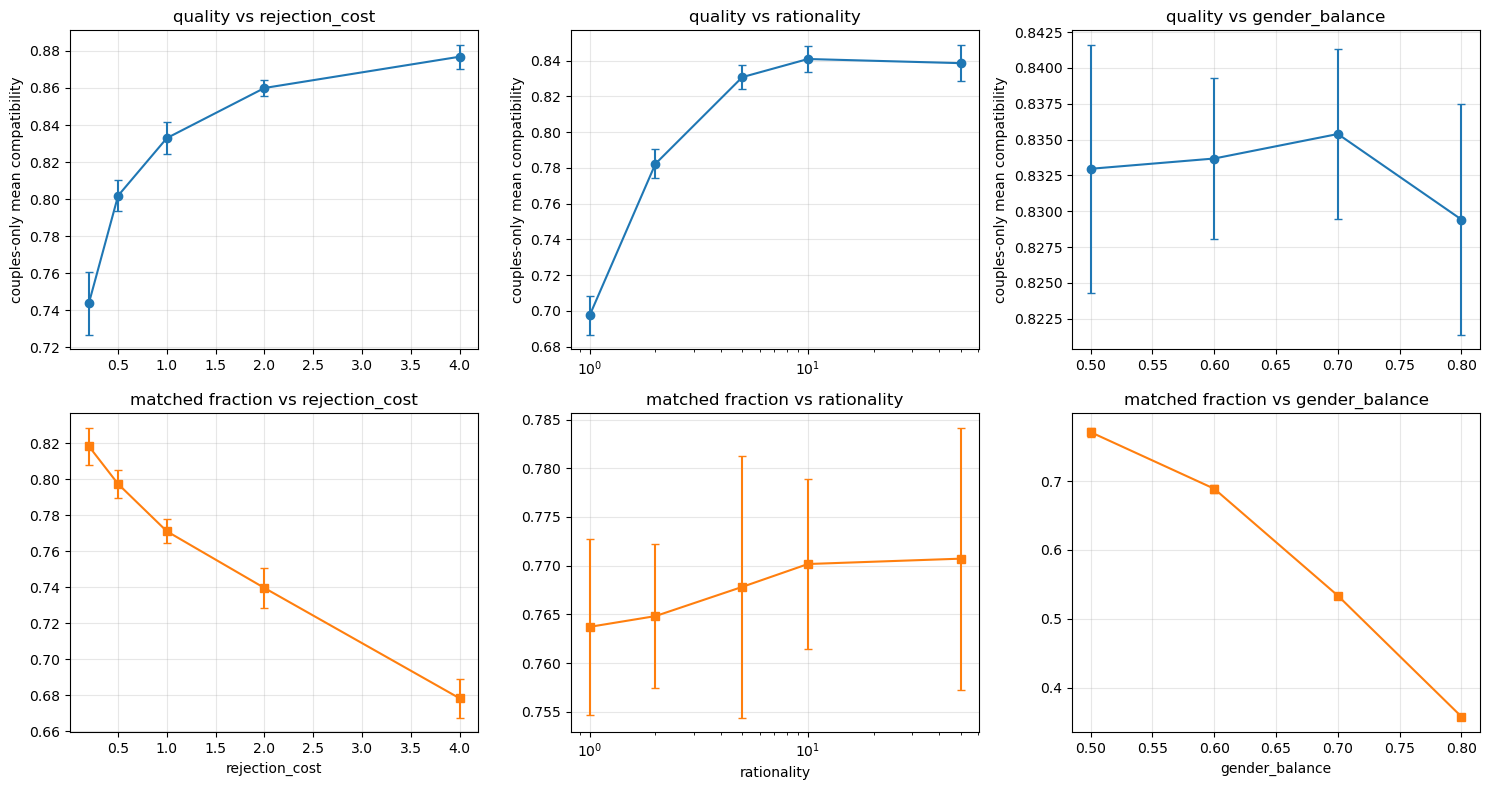

In [ ]:
# Homogeneous system - check the effct of paras seperately
BASE = dict(rejection_cost=1.0, rationality=6.0, gender_balance=0.5)
sweeps = {
    "rejection_cost": [0.2, 0.5, 1.0, 2.0, 4.0],
    "rationality":    [1.0, 2.0, 5.0, 10.0, 50.0],
    "gender_balance": [0.5, 0.6, 0.7, 0.8],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, (param, values) in enumerate(sweeps.items()):
    qm, qs, fm, fs = [], [], [], []
    for v in values:
        kw = {**BASE, param: v}
        a, b, c, d = replicate(**kw)
        qm.append(a); qs.append(b); fm.append(c); fs.append(d)
    axes[0, j].errorbar(values, qm, yerr=qs, marker="o", capsize=3)
    axes[0, j].set_title(f"quality vs {param}"); axes[0, j].grid(alpha=0.3)
    axes[0, j].set_ylabel("couples-only mean compatibility")
    axes[1, j].errorbar(values, fm, yerr=fs, marker="s", capsize=3, color="C1")
    axes[1, j].set_title(f"matched fraction vs {param}"); axes[1, j].grid(alpha=0.3)
    axes[1, j].set_xlabel(param)
    if param == "rationality":
        axes[0, j].set_xscale("log"); axes[1, j].set_xscale("log")
plt.tight_layout(); plt.show()

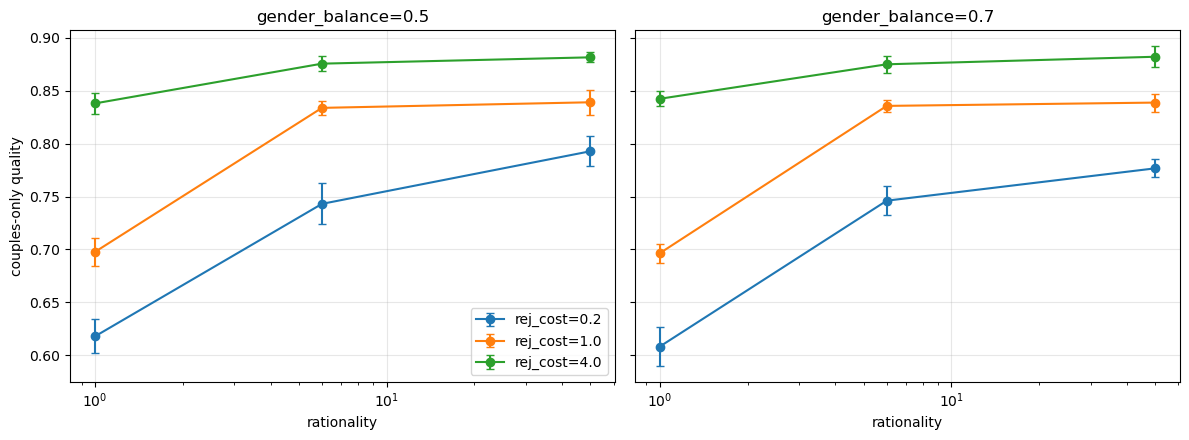

In [8]:
# Parameter interaction
MEMORY = 8

def couples_quality(m):
    v = [m.compatibility(a.id, a.partner) for a in m.subjects if not a.is_single]
    return float(np.mean(v)) if v else np.nan

def matched_fraction(m):
    return float(np.mean([not a.is_single for a in m.subjects]))

def run_homogeneous(rej, rat, gb, seed, n=240, n_grid=50,
                    n_steps=200, burn_in=80, thr=0.6):
    m = DatingMarket(n_grid=n_grid, interaction_std=0.5, interaction_radius=5,
                     relationship_length=10, seed=seed)
    m.add_agents(n, gender_balance=gb, rejection_cost=rej, rationality=rat,
                 relation_threshold=thr, memory_depth=MEMORY, move_prob=0.5)
    q, mf = [], []
    for t in range(n_steps):
        m.step()
        if t >= burn_in:
            q.append(couples_quality(m)); mf.append(matched_fraction(m))
    return np.nanmean(q), np.nanmean(mf)

rej_levels, rat_levels, gb_levels, seeds = [0.2,1.0,4.0], [1.0,6.0,50.0], [0.5,0.7], range(8)

rows = []
for rej, rat, gb, s in product(rej_levels, rat_levels, gb_levels, seeds):
    q, mf = run_homogeneous(rej, rat, gb, s)
    rows.append(dict(rejection_cost=rej, rationality=rat,
                     gender_balance=gb, seed=s, quality=q, matched=mf))
df = pd.DataFrame(rows)

# visual interaction test: faceted by gender_balance, one line per rejection_cost
fig, axes = plt.subplots(1, len(gb_levels), figsize=(6*len(gb_levels),4.5), sharey=True)
for ax, gb in zip(np.atleast_1d(axes), gb_levels):
    sub = df[df.gender_balance == gb]
    for rej in rej_levels:
        g = sub[sub.rejection_cost==rej].groupby("rationality")["quality"]
        ax.errorbar(g.mean().index, g.mean().values, yerr=g.std().values,
                    marker="o", capsize=3, label=f"rej_cost={rej}")
    ax.set_xscale("log"); ax.set_title(f"gender_balance={gb}")
    ax.set_xlabel("rationality"); ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel("couples-only quality")
np.atleast_1d(axes)[0].legend(); plt.tight_layout(); plt.show()

In [11]:
model = smf.ols("quality ~ C(rejection_cost)*C(rationality)*C(gender_balance)",
                data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)
anova["pct_var"] = 100 * anova["sum_sq"] / anova["sum_sq"].sum()
print(anova[["sum_sq","pct_var"]].round(3))

                                                    sum_sq  pct_var
C(rejection_cost)                                    0.553   52.439
C(rationality)                                       0.394   37.371
C(gender_balance)                                    0.000    0.014
C(rejection_cost):C(rationality)                     0.089    8.467
C(rejection_cost):C(gender_balance)                  0.001    0.054
C(rationality):C(gender_balance)                     0.000    0.026
C(rejection_cost):C(rationality):C(gender_balance)   0.001    0.053
Residual                                             0.017    1.576


In [9]:
# strategy interaction

def run_mixed(strategies, seed, gb=0.5, n_per=80, n_grid=50,
              n_steps=200, burn_in=80, thr=0.6):
    m = DatingMarket(n_grid=n_grid, interaction_std=0.5, interaction_radius=5,
                     relationship_length=10, seed=seed)
    label = {}
    for st in strategies:
        sid = m.add_agents(n_per, gender_balance=gb, rejection_cost=st["rejection_cost"],
                           rationality=st["rationality"], relation_threshold=thr,
                           memory_depth=MEMORY, move_prob=0.5, label=st["label"])
        label[sid] = st["label"]
    acc = {sid: [] for sid in label}
    for t in range(n_steps):
        m.step()
        if t >= burn_in:
            for sid in label:
                mem = [a for a in m.subjects if a.strategy_id==sid and not a.is_single]
                if mem:
                    acc[sid].append(np.mean([m.compatibility(a.id, a.partner) for a in mem]))
    return {label[sid]: (np.nanmean(v) if v else np.nan) for sid, v in acc.items()}

strat_grid = [
    dict(rejection_cost=0.2, rationality=50.0, label="bold-rational"),
    dict(rejection_cost=4.0, rationality=50.0, label="cautious-rational"),
    dict(rejection_cost=0.2, rationality=1.0,  label="bold-random"),
    dict(rejection_cost=4.0, rationality=1.0,  label="cautious-random"),
]
seeds = range(8)

mixed = pd.DataFrame([run_mixed(strat_grid, s) for s in seeds]).mean()
baseline = pd.Series({st["label"]:
    np.mean([run_homogeneous(st["rejection_cost"], st["rationality"], 0.5, s)[0]
             for s in seeds]) for st in strat_grid})
print("competitive effect (mix - alone):\n", (mixed - baseline).round(3))

# does gender imbalance flip the competitive ranking?
for gb in [0.5, 0.6, 0.7, 0.8]:
    res = pd.DataFrame([run_mixed(strat_grid, s, gb=gb) for s in seeds]).mean()
    print(f"gb={gb}:", res.round(3).to_dict())

competitive effect (mix - alone):
 bold-rational        0.010
cautious-rational   -0.023
bold-random          0.125
cautious-random     -0.011
dtype: float64
gb=0.5: {'bold-rational': 0.803, 'cautious-rational': 0.859, 'bold-random': 0.743, 'cautious-random': 0.827}
gb=0.6: {'bold-rational': 0.799, 'cautious-rational': 0.861, 'bold-random': 0.734, 'cautious-random': 0.826}
gb=0.7: {'bold-rational': 0.79, 'cautious-rational': 0.856, 'bold-random': 0.721, 'cautious-random': 0.821}
gb=0.8: {'bold-rational': 0.776, 'cautious-rational': 0.857, 'bold-random': 0.726, 'cautious-random': 0.828}


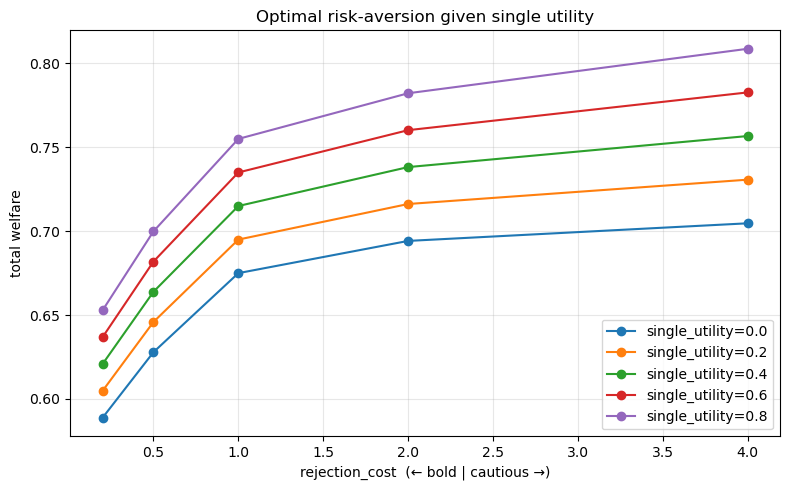

In [3]:
results_df = pd.DataFrame({
    "rejection_cost":    [0.2,   0.5,   1.0,   2.0,   4.0],
    "mean_quality":      [0.64,  0.69,  0.75,  0.78,  0.81],   # from your sweep
    "matched_fraction":  [0.92,  0.91,  0.90,  0.89,  0.87],   # from your sweep
})

single_utilities = [0.0, 0.2, 0.4, 0.6, 0.8]   # sweep over these

fig, ax = plt.subplots(figsize=(8, 5))

for su in single_utilities:
    results_df["total_utility"] = (
        results_df["matched_fraction"] * results_df["mean_quality"]
        + (1 - results_df["matched_fraction"]) * su
    )
    ax.plot(results_df["rejection_cost"], results_df["total_utility"],
            marker="o", label=f"single_utility={su}")

ax.set_xlabel("rejection_cost  (← bold | cautious →)")
ax.set_ylabel("total welfare")
ax.set_title("Optimal risk-aversion given single utility")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()